✅ Thư viện và thư mục đã sẵn sàng.
⏳ Đang tải dữ liệu...
   Dữ liệu gốc: 28900 dòng.
⚙️ Đang Reindexing (Lấp đầy ngày thiếu)...
   Dữ liệu sau Reindex: 73100 dòng.
🛠️ Đang tạo Features (Lags & Rolling)...
   Đang mã hóa One-Hot các cột: ['Category', 'Region', 'Seasonality', 'Weather Condition', 'Holiday/Promotion']
   Dữ liệu sẵn sàng train: 71700 dòng.
   Features đầu vào (12): ['Inventory Level', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount'] ...

🚀 BẮT ĐẦU TRAINING (RandomizedSearch 40 trials)...

✅ HOÀN TẤT TRAINING!
📊 RMSE Trung bình toàn cục: 62.3575

🔬 ĐANG THỰC HIỆN CHẨN ĐOÁN (QC)...
   -> Vẽ Learning Curve...


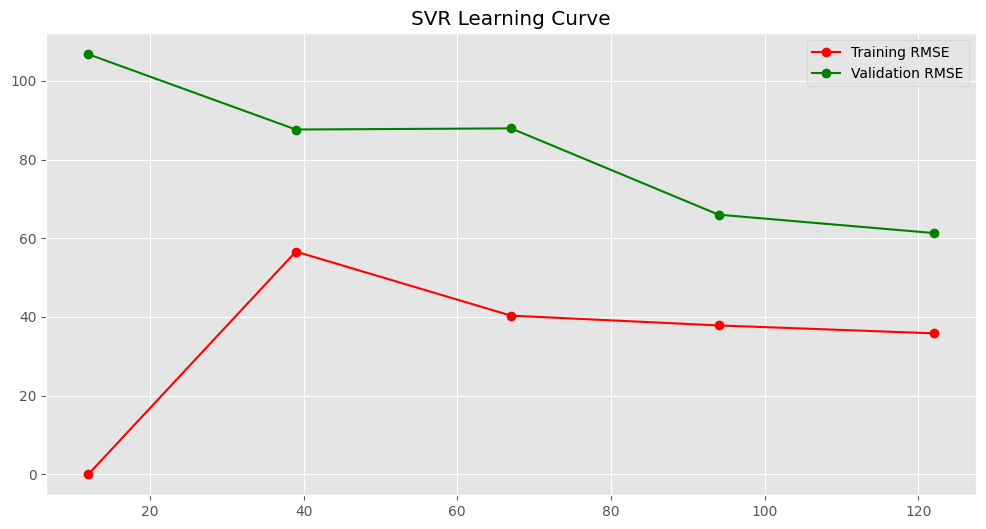

   -> Vẽ Residuals...


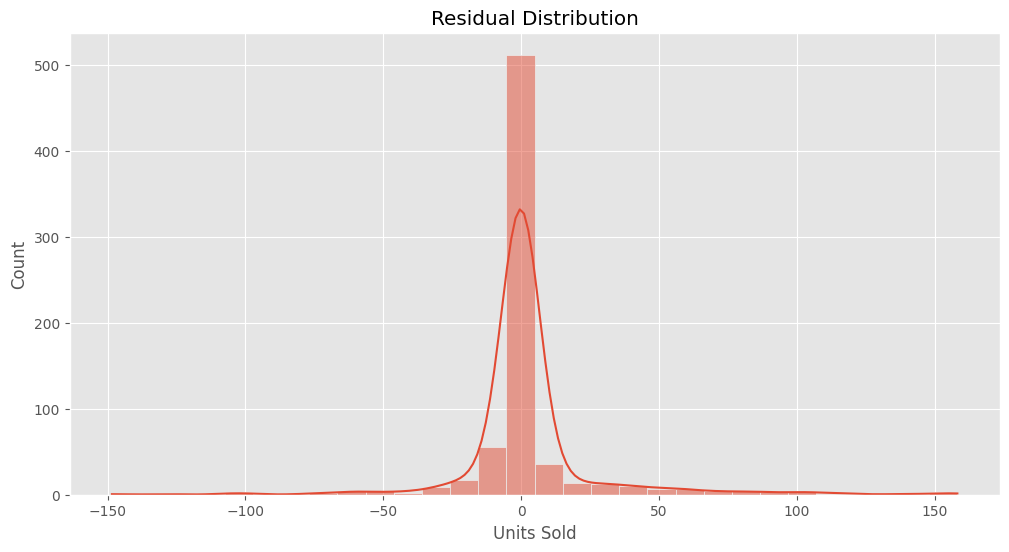

   -> Kiểm tra độ nhạy Epsilon...


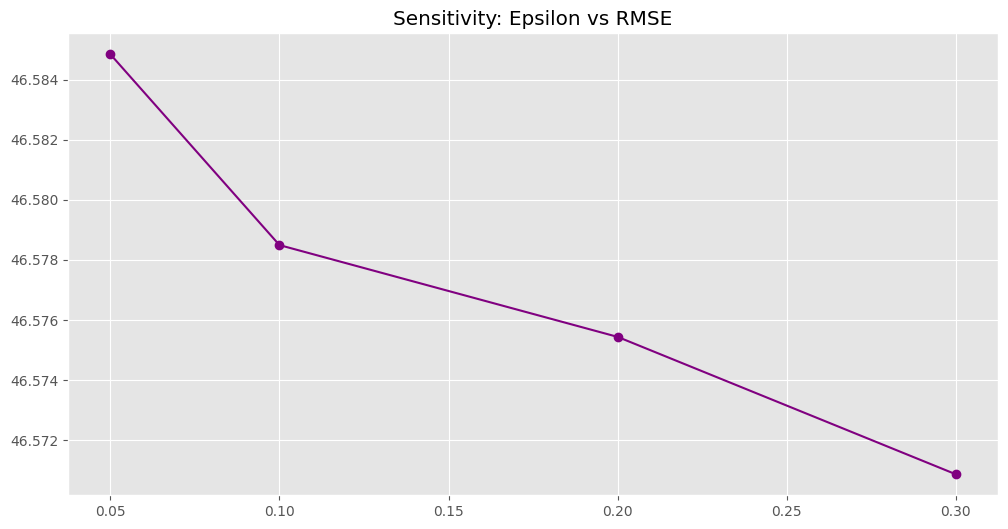


📦 Đang nén file nộp bài...
updating: models/ (stored 0%)
updating: preds/ (stored 0%)
updating: plots/ (stored 0%)
  adding: models/svr_S003_P0017.pkl (deflated 60%)
  adding: models/svr_S005_P0008.pkl (deflated 59%)
  adding: models/svr_S004_P0014.pkl (deflated 59%)
  adding: models/svr_S005_P0001.pkl (deflated 61%)
  adding: models/svr_S001_P0017.pkl (deflated 60%)
  adding: models/svr_S005_P0015.pkl (deflated 59%)
  adding: models/svr_S004_P0018.pkl (deflated 59%)
  adding: models/svr_S002_P0020.pkl (deflated 61%)
  adding: models/svr_S002_P0006.pkl (deflated 58%)
  adding: models/svr_S003_P0012.pkl (deflated 58%)
  adding: models/svr_S005_P0005.pkl (deflated 57%)
  adding: models/svr_S001_P0008.pkl (deflated 62%)
  adding: models/svr_S004_P0006.pkl (deflated 58%)
  adding: models/svr_S001_P0009.pkl (deflated 58%)
  adding: models/svr_S004_P0004.pkl (deflated 62%)
  adding: models/svr_S002_P0014.pkl (deflated 60%)
  adding: models/svr_S001_P0018.pkl (deflated 57%)
  adding: models/

In [3]:
# =============================================================================
# ĐỒ ÁN: DỰ BÁO TỒN KHO VỚI SVR (FINAL FIX - DỮ LIỆU THỰC TẾ)
# Fixes: Xử lý cột 'Weather Condition', 'Seasonality', 'Category', 'Region'
# =============================================================================

# --- 1. IMPORT THƯ VIỆN & SETUP ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

# Sklearn Libraries
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, learning_curve
from sklearn.feature_selection import SelectKBest, mutual_info_regression 

warnings.filterwarnings("ignore")
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

# Tạo thư mục Deliverables
os.makedirs('models', exist_ok=True)
os.makedirs('preds', exist_ok=True)
os.makedirs('plots', exist_ok=True)

print("✅ Thư viện và thư mục đã sẵn sàng.")

# --- 2. TẢI VÀ LÀM SẠCH DỮ LIỆU ---
print("⏳ Đang tải dữ liệu...")
file_path = '/kaggle/input/retail-store-inventory-forecasting-dataset/retail_store_inventory.csv'

# Tìm file tự động
if not os.path.exists(file_path):
    for root, dirs, files in os.walk('/kaggle/input'):
        for file in files:
            if file.endswith(".csv"):
                file_path = os.path.join(root, file)
                break

df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# 1. Format Date (Dữ liệu của bạn dạng 01/01/2022 -> dayfirst=True hoặc để auto)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Date'])

# 2. Xóa trùng lặp
df = df.drop_duplicates()

# 3. Sort
df = df.sort_values(by=['Store ID', 'Product ID', 'Date']).reset_index(drop=True)

print(f"   Dữ liệu gốc: {len(df)} dòng.")

# --- 3. TIỀN XỬ LÝ: REINDEXING ---
print("⚙️ Đang Reindexing (Lấp đầy ngày thiếu)...")

def reindex_group(group):
    full_idx = pd.date_range(start=group['Date'].min(), end=group['Date'].max(), freq='D')
    group = group.set_index('Date').reindex(full_idx)
    
    # Fill ID
    group['Store ID'] = group['Store ID'].ffill().bfill()
    group['Product ID'] = group['Product ID'].ffill().bfill()
    
    # Fill Target = 0
    group['Units Sold'] = group['Units Sold'].fillna(0)
    
    # Fill các biến khác (Forward Fill để lấp đầy Weather/Seasonality/Price)
    # Lấy tất cả cột trừ target và ID để fill
    cols_to_fill = [c for c in group.columns if c not in ['Store ID', 'Product ID', 'Units Sold']]
    for c in cols_to_fill:
        group[c] = group[c].ffill().bfill()
            
    group.index.name = 'Date'
    return group.reset_index()

df_reindexed = df.groupby(['Store ID', 'Product ID']).apply(reindex_group).reset_index(drop=True)
print(f"   Dữ liệu sau Reindex: {len(df_reindexed)} dòng.")

# --- 4. FEATURE ENGINEERING ---
print("🛠️ Đang tạo Features (Lags & Rolling)...")

def create_features(group_df):
    d = group_df.copy()
    target = 'Units Sold'
    
    # Lags
    d['lag_1'] = d[target].shift(1)
    d['lag_7'] = d[target].shift(7)
    d['lag_14'] = d[target].shift(14)
    
    # Rolling Means
    d['roll7_mean'] = d[target].shift(1).rolling(window=7, min_periods=1).mean()
    d['roll14_mean'] = d[target].shift(1).rolling(window=14, min_periods=1).mean()
    d['roll28_mean'] = d[target].shift(1).rolling(window=28, min_periods=1).mean()
    
    return d

df_feats = df_reindexed.groupby(['Store ID', 'Product ID'], group_keys=False).apply(create_features)

# --- MÃ HÓA (XỬ LÝ CÁC CỘT CHỮ TRONG DATA CỦA BẠN) ---
# Danh sách các cột chữ cần chuyển sang số
categorical_cols = ['Category', 'Region', 'Seasonality', 'Weather Condition', 'Holiday/Promotion'] 

# Chỉ lấy các cột thực sự tồn tại trong file
existing_cats = [c for c in categorical_cols if c in df_feats.columns]
if existing_cats:
    print(f"   Đang mã hóa One-Hot các cột: {existing_cats}")
    # drop_first=True để tránh đa cộng tuyến
    df_feats = pd.get_dummies(df_feats, columns=existing_cats, drop_first=True)

# Loại bỏ NaNs do Lags
df_final = df_feats.dropna()

# --- CHỐT CHẶN AN TOÀN TUYỆT ĐỐI ---
# Chỉ giữ lại các cột SỐ (Numeric).
# Điều này sẽ loại bỏ Store ID, Product ID (dạng S001, P001) ra khỏi X để không gây lỗi
df_numeric = df_final.select_dtypes(include=[np.number])

# Giữ lại cột ID và Date để Groupby (nhưng không đưa vào train)
df_final = pd.concat([df_final[['Date', 'Store ID', 'Product ID']], df_numeric], axis=1)
# Xóa cột trùng (nếu có)
df_final = df_final.loc[:, ~df_final.columns.duplicated()]

print(f"   Dữ liệu sẵn sàng train: {len(df_final)} dòng.")

# --- 5. ĐỊNH NGHĨA PIPELINE ---
# Features Input: Lấy tất cả cột số trừ ID và Target
features_col = [c for c in df_final.select_dtypes(include=[np.number]).columns 
                if c not in ['Units Sold']]

print(f"   Features đầu vào ({len(features_col)}): {features_col[:5]} ...")

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=mutual_info_regression)), 
    ('model', SVR(kernel='rbf'))
])

param_dist = {
    'selector__k': [8, 10, 12],
    'model__C': [1, 10, 50, 100],
    'model__epsilon': [0.05, 0.1, 0.2, 0.3],
    'model__gamma': ['scale', 'auto']
}

tscv = TimeSeriesSplit(n_splits=5)

# --- 6. TRAINING LOOP ---
print("\nBẮT ĐẦU TRAINING (RandomizedSearch 40 trials)...")

results = []
all_preds = []
best_global_model = None
best_global_score = float('inf')
model_for_qc = None 
data_for_qc = None

groups = df_final.groupby(['Store ID', 'Product ID'])

for (store, prod), group_data in groups:
    # Bỏ qua nếu chuỗi quá ngắn
    if len(group_data) < 30:
        continue
        
    # Lấy dữ liệu train (Chắc chắn chỉ có số)
    X = group_data[features_col]
    y = group_data['Units Sold']
    
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist,
        n_iter=40, 
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    
    try:
        search.fit(X, y)
        
        best_model = search.best_estimator_
        rmse = -search.best_score_
        
        results.append({'Store': store, 'Product': prod, 'RMSE': rmse})
        
        joblib.dump(best_model, f"models/svr_{store}_{prod}.pkl")
        
        y_pred = best_model.predict(X)
        pred_df = group_data[['Date', 'Store ID', 'Product ID', 'Units Sold']].copy()
        pred_df['Predicted'] = y_pred
        pred_df.to_csv(f"preds/svr_{store}_{prod}.csv", index=False)
        all_preds.append(pred_df)
        
        if rmse < best_global_score:
            best_global_score = rmse
            best_global_model = best_model
            model_for_qc = best_model
            data_for_qc = (X, y)
            
    except Exception as e:
        print(f"❌ Lỗi {store}-{prod}: {str(e)}")

print("\n✅ HOÀN TẤT TRAINING!")

# --- 7. TỔNG HỢP KẾT QUẢ ---
if len(results) > 0:
    res_df = pd.DataFrame(results)
    avg_rmse = res_df['RMSE'].mean()
    print(f" RMSE Trung bình toàn cục: {avg_rmse:.4f}")
    
    full_preds = pd.concat(all_preds)
    full_preds.to_csv("preds/svr_all_predictions.csv", index=False)
else:
    print("Không có mô hình nào chạy thành công.")

# --- 8. CHẨN ĐOÁN (QC) ---
if model_for_qc is not None:
    print("\n🔬 ĐANG THỰC HIỆN CHẨN ĐOÁN (QC)...")
    X_qc, y_qc = data_for_qc
    
    # A. Learning Curve
    print("   -> Vẽ Learning Curve...")
    train_sizes, train_scores, test_scores = learning_curve(
        model_for_qc, X_qc, y_qc, cv=tscv, 
        scoring='neg_root_mean_squared_error', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    plt.figure()
    plt.plot(train_sizes, -np.mean(train_scores, axis=1), 'o-', color="r", label="Training RMSE")
    plt.plot(train_sizes, -np.mean(test_scores, axis=1), 'o-', color="g", label="Validation RMSE")
    plt.title("SVR Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.savefig('plots/learning_curve.png')
    plt.show()
    
    # B. Residuals
    print("   -> Vẽ Residuals...")
    preds_qc = model_for_qc.predict(X_qc)
    residuals = y_qc - preds_qc
    
    plt.figure()
    sns.histplot(residuals, kde=True, bins=30)
    plt.title("Residual Distribution")
    plt.savefig('plots/residual_dist.png')
    plt.show()
    
    # C. Sensitivity (Epsilon)
    print("   -> Kiểm tra độ nhạy Epsilon...")
    epsilons = [0.05, 0.1, 0.2, 0.3]
    scaler = model_for_qc.named_steps['scaler']
    selector = model_for_qc.named_steps['selector']
    svr_params = model_for_qc.named_steps['model'].get_params()
    
    val_scores = []
    for eps in epsilons:
        test_svr = SVR(kernel='rbf', C=svr_params['C'], gamma=svr_params['gamma'], epsilon=eps)
        test_pipe = Pipeline([('scaler', scaler), ('selector', selector), ('model', test_svr)])
        from sklearn.model_selection import cross_val_score
        scores = cross_val_score(test_pipe, X_qc, y_qc, cv=tscv, scoring='neg_root_mean_squared_error')
        val_scores.append(-np.mean(scores))
        
    plt.figure()
    plt.plot(epsilons, val_scores, 'o-', color='purple')
    plt.title("Sensitivity: Epsilon vs RMSE")
    plt.grid(True)
    plt.savefig('plots/sensitivity_epsilon.png')
    plt.show()

print("\n📦 Đang nén file nộp bài...")
!zip -r svr_deliverables.zip models preds plots
print("🎉 ĐÃ XONG! Tải file 'svr_deliverables.zip' về.")